In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df_fear_greed = pd.read_csv("datasets/fear_greed_index.csv")
df_historical_data = pd.read_csv("datasets/historical_data.csv")

# **Bitcoin Market Sentiment Dataset**


In [4]:
df_fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [5]:
print("Number of (rows,columns):",df_fear_greed.shape)
print("Number of duplicated values:",df_fear_greed.duplicated().sum())
print("Number of null values in each column:")
df_fear_greed.isnull().sum()

Number of (rows,columns): (2644, 4)
Number of duplicated values: 0
Number of null values in each column:


timestamp         0
value             0
classification    0
date              0
dtype: int64

In the Bitcoin Market Sentiment dataset there are **2644 rows** and **4 columns** with neither duplicate values nor null values

# **Historical Trader Dataset**

In [6]:
df_historical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [7]:
df_historical_data.columns = df_historical_data.columns.str.lower()

In [8]:
print("Number of (rows,columns):",df_historical_data.shape)
print("Number of duplicated values:",df_historical_data.duplicated().sum())
print("Number of null values in each column:")
df_historical_data.isnull().sum()

Number of (rows,columns): (211224, 16)
Number of duplicated values: 0
Number of null values in each column:


account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
dtype: int64

In the Historical Trader Dataset there are **215853 rows** and **16 columns** with **4628 duplicated values** and **1 null value each** in the columns **start position, direction, closed pnl, transaction hash,order id, crossed, fee, trade id and timestamp**.

#**Cleaning Historical Trader Dataset**

In [9]:
df_historical_data.drop_duplicates(inplace=True)
df_historical_data.dropna(subset=["trade id","timestamp","start position","direction","closed pnl","transaction hash","order id","crossed","fee"],inplace=True)

# **Correcting Timestamps and merging the dataframes**


Dropping the corrupted **timestamp** column

In [10]:
df_historical_data.drop(columns=["timestamp"],inplace=True,axis=1)

The cryptocurrency market and the Fear/Greed Index operate on a 24/7 global standard UTC. The **column for timestamp given to me was in IST** which is 5 hours and 30 minutes ahead of UTC. So to bring the timestamps for both the datasets to the same units I converted the timestamp to UTC by **deducting 5h30m from the timestamp ist column to convert it to the standard UTC**

In [11]:
df_historical_data["timestamp ist"] = pd.to_datetime(df_historical_data["timestamp ist"], format="%d-%m-%Y %H:%M")
df_historical_data["timestamp utc"] = df_historical_data["timestamp ist"] - pd.Timedelta(hours=5, minutes=30)
df_historical_data["date"] = df_historical_data["timestamp utc"].dt.date

In [12]:
df_fear_greed["date"] = pd.to_datetime(df_fear_greed["date"]).dt.date

Merging the dataframes on the **date column**  with **Inner join** to include the row elements occuring in both tables

In [13]:
df_merged = pd.merge(df_historical_data, df_fear_greed, on="date", how="inner")

print("Merged Data (rows,columns):", df_merged.shape)
df_merged.head()

Merged Data (rows,columns): (211224, 20)


,account,coin,execution price,size tokens,size usd,side,timestamp ist,start position,direction,closed pnl,transaction hash,order id,crossed,fee,trade id,timestamp utc,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-12-02 17:20:00,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-12-02 17:20:00,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-12-02 17:20:00,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-12-02 17:20:00,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-12-02 17:20:00,2024-12-02,1733117400,80,Extreme Greed


Dropping unwanted columns from the merged dataframe

In [14]:
columns_to_drop = ['transaction hash','order id','trade id','timestamp ist','timestamp utc','crossed']
df_merged.drop(columns=columns_to_drop, inplace=True, axis=1)
print("Final merged dataset columns:\n", df_merged.columns.tolist())

Final merged dataset columns:
 ['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side', 'start position', 'direction', 'closed pnl', 'fee', 'date', 'timestamp', 'value', 'classification']


# **Feature Engineering**

In [15]:
daily_metrics = df_merged.groupby(['date', 'account', 'classification']).apply(
    lambda x: pd.Series({
        'daily_pnl': x['closed pnl'].sum(),
        'trade_count': len(x),
        'win_rate': (x['closed pnl'] > 0).sum() / len(x) * 100 if len(x) > 0 else 0,
        'avg_trade_size': x['size usd'].mean(),
        'long_short_ratio': (x['direction'].str.title() == 'Long').sum() /
                           max(1, (x['direction'].str.title() == 'Short').sum())
    })
).reset_index()

print(f"Daily Metrics Shape: {daily_metrics.shape}")
print("\nDaily Metrics Sample")
daily_metrics.head(10)

Daily Metrics Shape: (2343, 8)

Daily Metrics Sample


C:\Users\kusha\AppData\Local\Temp\ipykernel_16084\1238662376.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_metrics = df_merged.groupby(['date', 'account', 'classification']).apply(


,date,account,classification,daily_pnl,trade_count,win_rate,avg_trade_size,long_short_ratio
0,2023-04-30,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,3.0,0.000000,159.000000,0.0
1,2023-12-04,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,9.0,0.000000,5556.203333,0.0
2,2023-12-13,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-281.804639,3.0,33.333333,16926.133333,0.0
3,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,51.737868,10.0,30.000000,7303.490000,0.0
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,329.708097,11.0,63.636364,8379.370000,0.0
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.725312,6.0,0.000000,6575.620000,0.0
6,2023-12-18,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,2.0,0.000000,15582.090000,0.0
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,1062.278674,25.0,60.000000,6916.665200,0.0
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,230.269674,41.0,48.780488,3499.075366,0.0
9,2023-12-21,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,407.933948,21.0,42.857143,3411.030476,0.0


**Daily PnL**: Sum of closed PnL for all trades on that day

**Trade Count**: Number of trades executed

**Win Rate**: Percentage of winning trades

**Average Trade Size**: Mean USD value of trades

**Long/Short Ratio**: Ratio of long positions to short positions

# **Market behaviour analysis based on the sentiments**

In [16]:
sentiment_comparison = daily_metrics.groupby('classification')[['daily_pnl', 'win_rate', 'trade_count', 'avg_trade_size']].median()
print("Median Behavior by Sentiment")
sentiment_comparison

Median Behavior by Sentiment


,daily_pnl,win_rate,trade_count,avg_trade_size
classification,,,,
Extreme Fear,329.002855,33.879781,47.0,2360.909310
Extreme Greed,391.905230,35.851243,30.0,1947.846142
Fear,112.545593,30.933852,29.0,1747.178679
Greed,173.322327,28.571429,25.0,2147.341250
Neutral,178.567901,33.333333,29.0,1683.015568


C:\Users\kusha\AppData\Local\Temp\ipykernel_16084\2136143316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='classification', y='win_rate', data=daily_metrics, palette='Set2')


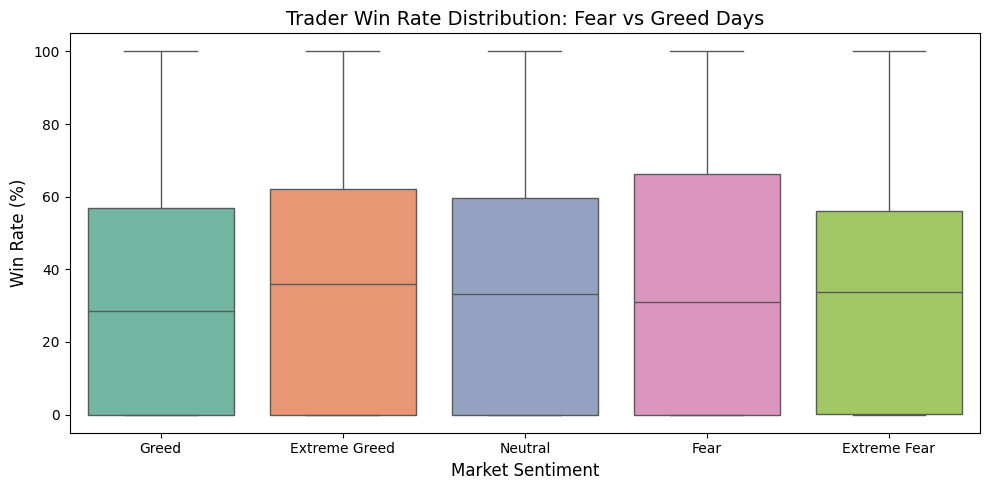

In [17]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='classification', y='win_rate', data=daily_metrics, palette='Set2')
plt.title('Trader Win Rate Distribution: Fear vs Greed Days', fontsize=14)
plt.ylabel('Win Rate (%)', fontsize=12)
plt.xlabel('Market Sentiment', fontsize=12)
plt.tight_layout()
plt.show()

The box plots show that extreme sentiment days (both Fear and Greed) have a wider spread of outcomes, indicating higher risk and opportunity. Extreme Fear has a median win rate of 33.88% while Extreme Greed has a slightly higher median win rate of 35.85%

C:\Users\kusha\AppData\Local\Temp\ipykernel_16084\3157087393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='classification', y='trade_count', data=daily_metrics, palette='Set1', estimator=np.mean)


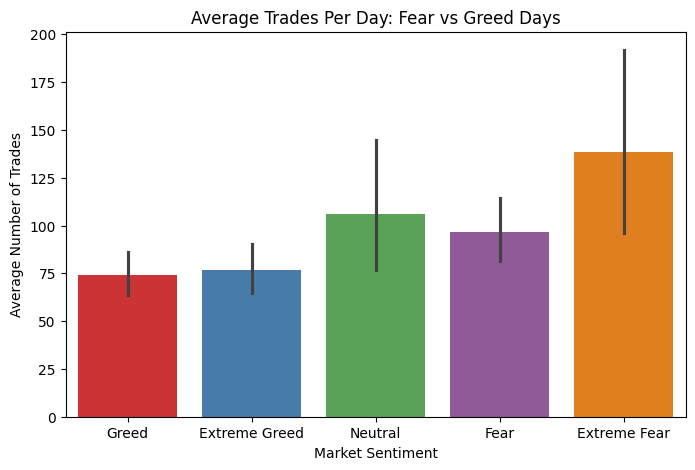

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(x='classification', y='trade_count', data=daily_metrics, palette='Set1', estimator=np.mean)
plt.title('Average Trades Per Day: Fear vs Greed Days')
plt.ylabel('Average Number of Trades')
plt.xlabel('Market Sentiment')
plt.show()


During Extreme Fear days, the average number of trades rise abruptly compared to other days suggesting that when the market crashes, traders become reactive

# **Trader segmentation.**

 The Whale represents the traders with high volume trade size while Retail represents the traders with relatively lower volume trade size

In [19]:
median_trade_size = daily_metrics['avg_trade_size'].median()
daily_metrics['trader_type'] = np.where(daily_metrics['avg_trade_size'] >= median_trade_size, 'Whale', 'Retail')

In [20]:
segment_pnl = daily_metrics.groupby(['trader_type', 'classification'])['daily_pnl'].median()
print("\nMedian Daily PnL by Trader Size and Sentiment:")
segment_pnl


Median Daily PnL by Trader Size and Sentiment:


trader_type  classification
Retail       Extreme Fear       192.287031
             Extreme Greed      231.156105
             Fear                51.207696
             Greed              127.094950
             Neutral             93.000520
Whale        Extreme Fear      1593.793350
             Extreme Greed      769.466696
             Fear               459.153994
             Greed              279.185907
             Neutral            462.740727
Name: daily_pnl, dtype: float64

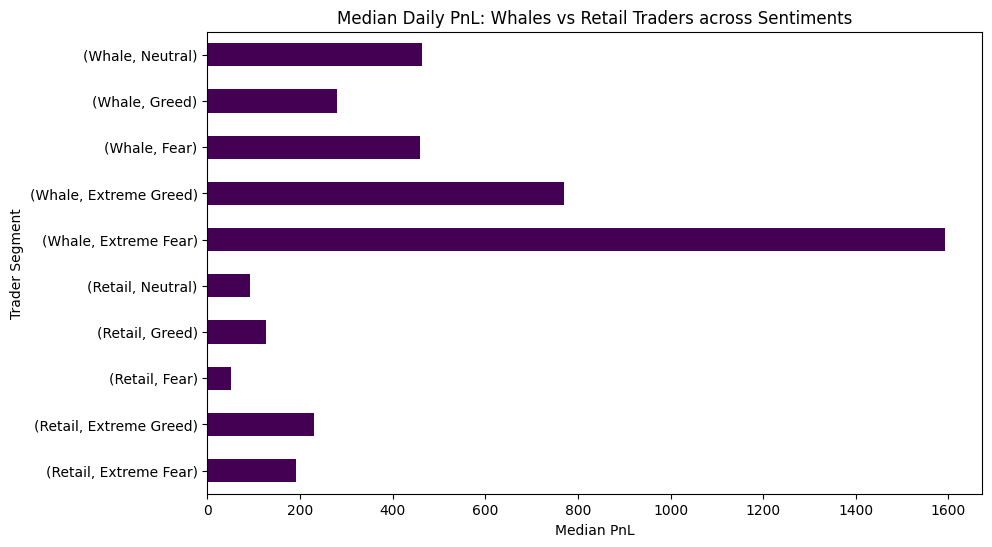

In [21]:
segment_pnl.plot(kind='barh', figsize=(10, 6), colormap='viridis')
plt.title('Median Daily PnL: Whales vs Retail Traders across Sentiments')
plt.xlabel('Median PnL')
plt.ylabel('Trader Segment')
plt.show()

<Figure size 1200x600 with 0 Axes>

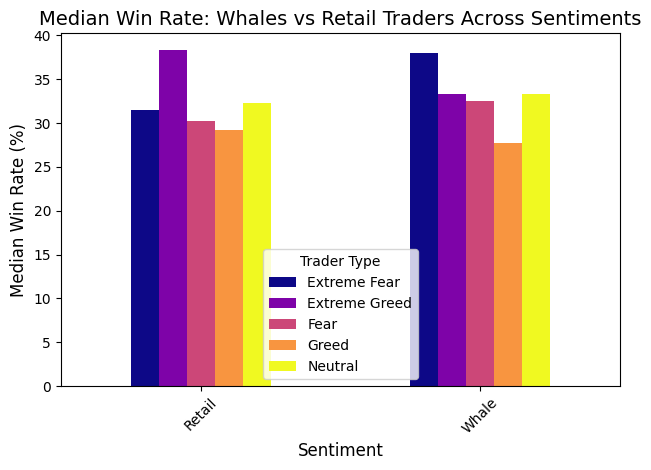

In [22]:
segment_win_rate = daily_metrics.groupby(['trader_type', 'classification'])['win_rate'].median().unstack()
plt.figure(figsize=(12, 6))
segment_win_rate.plot(kind='bar', colormap='plasma')
plt.title('Median Win Rate: Whales vs Retail Traders Across Sentiments', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Median Win Rate (%)', fontsize=12)
plt.legend(title='Trader Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Whales have consistently higher daily pnl than retail traders. While the Retail traders perform best during Extreme Greedy markets with a daily pnl of $231 ,the Whales show their best performance during Extreme Fear markets

Consistent winners have a win rate greater than the median win rate of the all traders and having a trade count>50

In [23]:
account_metrics = daily_metrics.groupby('account').agg({
    'win_rate': 'median',
    'trade_count': 'sum',
    'daily_pnl': 'sum'
}).reset_index()
overall_median_win_rate = daily_metrics['win_rate'].median()
print(f"Overall Median Win Rate: {overall_median_win_rate:.2f}%")
account_metrics['trader_consistency'] = np.where(
    (account_metrics['win_rate'] > overall_median_win_rate) & (account_metrics['trade_count'] > 50),
    'Consistent Winner',
    'Inconsistent'
)
print("\nTrader Consistency Distribution")
print(account_metrics['trader_consistency'].value_counts())

Overall Median Win Rate: 32.40%

Trader Consistency Distribution
trader_consistency
Inconsistent         21
Consistent Winner    11
Name: count, dtype: int64


In [24]:
daily_metrics = pd.merge(
    daily_metrics,
    account_metrics[['account', 'trader_consistency']],
    on='account',
    how='left'
)

In [25]:
consistency_pnl = daily_metrics.groupby(['trader_consistency', 'classification'])['daily_pnl'].median().unstack()
print("\nMedian Daily PnL by Trader Consistency and Sentiment")
consistency_pnl


Median Daily PnL by Trader Consistency and Sentiment


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
trader_consistency,,,,,
Consistent Winner,446.358633,1100.575140,379.777508,523.268033,302.036247
Inconsistent,268.367925,140.995116,6.904970,18.806690,122.753950


<Figure size 1200x600 with 0 Axes>

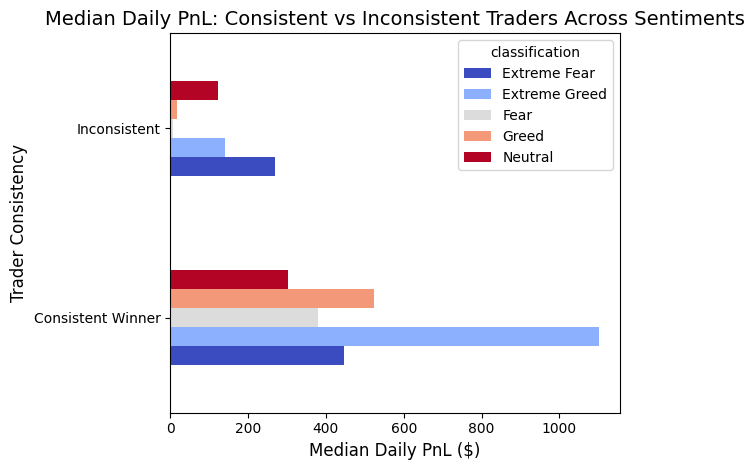

In [26]:
plt.figure(figsize=(12, 6))
consistency_pnl.plot(kind='barh', colormap='coolwarm')
plt.title('Median Daily PnL: Consistent vs Inconsistent Traders Across Sentiments', fontsize=14)
plt.xlabel('Median Daily PnL ($)', fontsize=12)
plt.ylabel('Trader Consistency', fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
consistency_win_rate = daily_metrics.groupby(['trader_consistency', 'classification'])['win_rate'].median().unstack()
print("\nMedian Win Rate by Trader Consistency and Sentiment")
consistency_win_rate



Median Win Rate by Trader Consistency and Sentiment


classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
trader_consistency,,,,,
Consistent Winner,41.369048,47.747748,47.058824,45.454545,44.117647
Inconsistent,28.571429,20.000000,9.834559,13.873626,16.666667


<Figure size 1200x600 with 0 Axes>

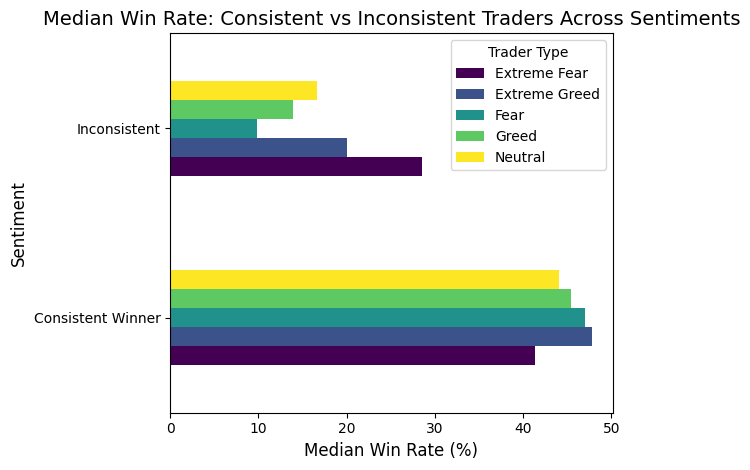

In [28]:
plt.figure(figsize=(12, 6))
consistency_win_rate.plot(kind='barh', colormap='viridis')
plt.title('Median Win Rate: Consistent vs Inconsistent Traders Across Sentiments', fontsize=14)
plt.ylabel('Sentiment', fontsize=12)
plt.xlabel('Median Win Rate (%)', fontsize=12)
plt.legend(title='Trader Type')
plt.tight_layout()
plt.show()

The consistent traders significantly outperform the inconsistent traders. The performance gap is the widest dring Extreme Fear and Extreme Greed days which suggests that consistency plays a crucial role.